# Project 3B T126 - Water Pipe Failure Prediction

This notebook provides a short end-to-end demonstration of the final project workflow.

Detailed exploratory work, preprocessing logic, modelling functions, and evaluation utilities are stored in separate `.py` files under `src/` folder.

## 1. Dataset Review and Final Selection

Several candidate datasets were reviewed to determine which dataset was most suitable for supervised pipe failure modelling.

The review focused on:

- dataset size and structure
- availability of historical failure records
- ability to link break records to pipe assets
- suitability for flat machine learning workflows
- availability of environmental or soil information

In [2]:
from src.dataset_review import run_dataset_review, display_dataset_summary

review_results = run_dataset_review(
    melbourne_mains_path="data/raw/Melbourne/Water_Supply_Main_Pipelines.csv",
    melbourne_soil_path="data/raw/Melbourne/Soil-Readings-Melbourne.csv",
    netherlands_mains_path="data/raw/Netherlands/Netherlands_watermains.pickle",
    netherlands_breaks_path="data/raw/Netherlands/Netherlands_watermainbreaks.npy",
    kitchener_mains_path="data/raw/Kitchener/Kitchener_watermains.csv",
    kitchener_breaks_path="data/raw/Kitchener/Kitchener_watermainbreaks.csv",
    bozeman_path="data/raw/Bozeman/Bozeman_watermainbreaks.csv",
)

display_dataset_summary(review_results)

,dataset,rows,columns,missing_cells,duplicate_rows
0,Melbourne Water Mains,12680,37,155063,0
1,Melbourne Soil Readings,905562,7,2784,0
2,Netherlands Water Mains,10203,12,0,0
3,Netherlands Break History,10203,12,0,1901
4,Kitchener Water Mains,16163,27,43861,0
5,Kitchener Water Main Breaks,2994,37,43688,0
6,Bozeman Water Main Breaks,158,12,48,0


Original Netherlands break history shape:
(10203, 6, 2)

Kitchener join key check:
{'mains_key': True, 'breaks_key': True}


### 1.1 Dataset shortlist summary

The review output highlighted major differences between the shortlisted datasets in terms of scale, structure and modelling suitability.

The Kitchener datasets provided the strongest foundation for supervised modelling, containing 16,163 water main asset records and 2,994 historical break records. The matching identifiers (`WATMAINID` and `Related Asset ID`) also confirmed that break events could be linked directly back to pipe assets to create a pipe-level target variable.

The Netherlands dataset contained 10,203 records and relatively complete feature data, but the break history was stored in a sequence-based 3D array with shape `(10203, 6, 2)`, making it less suitable for the planned flat machine learning workflow.

The Bozeman dataset only contained 158 records, which was considered too small for reliable model training and evaluation.

The Melbourne datasets provided large-scale operational and environmental data, including 12,680 water main records and more than 900,000 soil monitoring records. However, no historical break labels were available for supervised learning.

### 1.2 Final dataset decision

The **Kitchener dataset** was selected as the final modelling dataset because it provides:

- water main asset information
- historical break records
- usable matching between break records and pipe assets
- enough structure to create a pipe-level supervised learning dataset

### 1.3 External soil dataset result

The Kitchener dataset does not include soil or environmental attributes. Because soil conditions may influence pipe deterioration, two external Canadian soil datasets were tested using GIS spatial joins:

1. Ontario Soil Survey Complex  
2. CANSIS / Soil Landscapes of Canada

In [5]:
from src.external_soil_testing import (
    run_external_soil_testing,
    display_soil_testing_summary,
)

soil_results = run_external_soil_testing(
    breaks_path="data/processed/kitchener_breaks_clean.csv",
    ontario_soil_path="data/raw/Ontario Soil Survey Complex/Soil_Survey_Complex.geojson",
    slc_shp_path="data/raw/CANSIS SLC/ca_all_slc_v3r2.shp",
    cmp_path="data/raw/CANSIS SLC/ca_all_slc_v3r2_cmp.dbf",
    snt_path="data/raw/Ontario Soil Survey Complex/soil_name_canada_v2r20231107.dbf",
    output_latlon_path="data/processed/kitchener_breaks_latlon.csv",
)

display_soil_testing_summary(soil_results)

Ontario Soil Survey Complex
Matched rows: 2994
Total rows: 2994
Match %: 100.0

Top Ontario soil names:


SOIL_NAME1
URBAN                       2943
WATERLOO FINE SANDY LOAM      23
BURFORD GRAVELLY LOAM          7
LISBON SANDY LOAM              7
WATER                          4
BUILT UP AREA                  3
ELMIRA LOAM                    2
FOX SANDY LOAM                 2
ST CLEMENTS SILT LOAM          1
CALEDON SANDY LOAM             1
Name: count, dtype: int64


Top Ontario texture values (%):


ATEXTURE1
NA     98.53
FSL     0.77
SL      0.37
GL      0.23
L       0.07
SIL     0.03
Name: proportion, dtype: float64


CANSIS / Soil Landscapes of Canada
Matched polygon rows: 2994
Unmatched polygon rows: 0
Match %: 100.0

Top CANSIS soil names:


SOILNAME
FOX         1718
BURFORD      701
WATERLOO     572
GUELPH         3
Name: count, dtype: int64


CANSIS drainage distribution:


DRAINAGE
W    2994
Name: count, dtype: int64


CANSIS texture distribution:


PMTEX1
VC    2991
M        3
Name: count, dtype: int64

#### Soil testing result

Both GIS spatial joins achieved 100% coverage, with all 2,994 Kitchener break records matched to soil polygons.

However, the Ontario Soil Survey Complex results were dominated by broad urban classifications, with 2,943 records labelled as `URBAN` and 98.53% of texture values recorded as `NA`.

The CANSIS dataset produced cleaner soil attributes, but the results still showed limited variation. Most records fell into only three soil groups (`FOX`, `BURFORD`, and `WATERLOO`), while drainage and texture values were almost constant across the dataset.

Therefore, the external soil datasets were not included as final modelling features because they did not provide sufficient pipe-level discriminatory value for the modelling stage.

## 2. Kitchener Preprocessing Workflow

This section demonstrates the final preprocessing pipeline used to convert the raw Kitchener mains and break datasets into a clean pipe-level dataset for modelling.

**Preprocessing steps**

- cleans the raw mains and break source tables
- removes weak or high-missing fields
- standardises date and key fields
- links break records to water main assets
- aggregates event-level break history to pipe level
- creates the target variable `has_break`
- derives final modelling features such as `pipe_age`
- exports the final model-ready dataset

**Main output**

The main file used for modelling is:

- `data/processed/kitchener_model_ready.csv`

### 2.1 Run pre-processing

In [2]:
from src.kitchener_preprocessing import (
    run_kitchener_preprocessing,
    display_kitchener_preprocessing_summary,
    plot_target_distribution,
)

kitchener_results = run_kitchener_preprocessing(
    mains_path="data/raw/Kitchener/Kitchener_watermains.csv",
    breaks_path="data/raw/Kitchener/Kitchener_watermainbreaks.csv",
    output_dir="data/processed",
    save_outputs=True,
    verbose=False,
)

display_kitchener_preprocessing_summary(kitchener_results)

Raw data
Raw mains shape: (16163, 27)
Raw breaks shape: (2994, 37)

After cleaning
Cleaned mains shape: (16163, 22)
Cleaned breaks shape: (2994, 18)

Asset matching
{'asset_match_rate_pct': np.float64(81.9), 'matched_break_rows': 2452, 'unmatched_break_rows': 542}

MAIN break filtering
MAIN breaks shape: (2922, 18)
Matched MAIN breaks shape: (2451, 18)

Final datasets
Pipe-level dataset shape: (16163, 26)
Pipe master dataset shape: (16163, 28)
Model-ready dataset shape: (16163, 20)

Target distribution
has_break
0    14929
1     1234
Name: count, dtype: int64

Target distribution (%)
has_break
0    92.37
1     7.63
Name: proportion, dtype: float64


#### Kitchener preprocessing result

The preprocessing pipeline converted 16,163 raw water main records and 2,994 raw break records into a clean pipe-level modelling dataset.

After removing weak or high-missing fields, the mains dataset was reduced from 27 to 22 columns, and the breaks dataset was reduced from 37 to 18 columns. The asset matching step achieved an 81.9% match rate, with 2,452 break records linked to water main assets. After filtering to MAIN breaks only, 2,451 matched MAIN break records were used for pipe-level aggregation.

The final model-ready dataset contains 16,163 pipe records and 20 columns. The target variable is imbalanced, with 14,929 pipes having no observed break and 1,234 pipes having at least one observed break, meaning only 7.63% of pipes are positive cases.

### 2.2 Preview model-ready data

The model-ready dataset is the final processed Kitchener dataset used for model development. It contains one row per pipe and includes cleaned asset-level predictors plus the target variable `has_break`.

In [3]:
model_ready_df = kitchener_results["model_ready_df"]
display(model_ready_df.head())

,pressure_zone,category,pipe_size,material,lined,lined_material,acquisition,ownership,bridge_main,criticality,rel_cleaning_area,rel_cleaning_subarea,undersized,shallow_main,condition_score,oversized,cleaned,shape__length,has_break,pipe_age
0,KIT 6,TREATED,450,DI,0,NONE,DONATED,DUAL CITY AND REGION,0,6.0,6,8,0,0,8.50,0,0,34.210563,0,47.2
1,KIT 4,TREATED,300,DI,0,NONE,PURCHASED,REGION,0,7.0,1,4,0,0,8.50,0,0,0.355118,0,57.7
2,KIT 6,TREATED,450,DI,0,NONE,DONATED,DUAL CITY AND REGION,0,7.0,6,8,0,0,6.10,0,1,67.852910,1,47.2
3,KIT 6,TREATED,450,DI,0,NONE,DONATED,DUAL CITY AND REGION,0,6.0,6,8,0,0,4.58,0,1,7.039328,1,47.2
4,KIT 6,TREATED,450,DI,0,NONE,DONATED,DUAL CITY AND REGION,0,6.0,6,8,0,0,8.50,0,1,14.956131,0,47.2


### 2.3 Check class balance

The target distribution is checked before modelling because pipe failure prediction is an imbalanced classification problem.

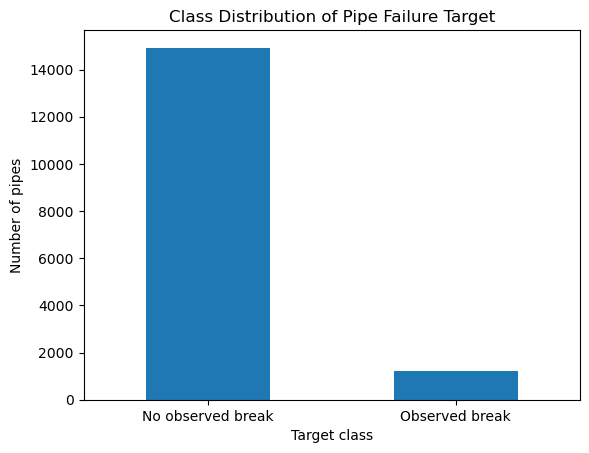

In [9]:
plot_target_distribution(kitchener_results["pipe_df"])

The target variable is highly imbalanced. Only 1,234 out of 16,163 pipes have an observed historical break, representing 7.63% of all records. This means accuracy alone is not enough for model evaluation, so later model comparison uses metrics such as precision, recall, F1-score, ROC-AUC and PR-AUC.

## 3. Kitchener - Model Development and Comparison
   
This section demonstrates the modelling workflow using the processed Kitchener pipe-level dataset.

The model-ready dataset from the preprocessing stage is used to train and compare three supervised classification models:

- Logistic Regression
- Random Forest
- XGBoost

### 3.1 Random Forest Modelling

This section demonstrates the Random Forest modelling workflow using the processed Kitchener model-ready dataset.

Random Forest was included because it can capture non-linear relationships between pipe attributes and historical break risk. It also provides feature importance values, which are useful for interpreting key risk drivers and supporting the later Melbourne adaptation stage.

In [10]:
from pathlib import Path

Path("outputs").mkdir(exist_ok=True)

import src.kitchener_random_forest as krf
import src.kitchener_xgboost as kxgb
import src.kitchener_logistic_regression as klr

In [11]:
from src.kitchener_random_forest import (
    run_random_forest_workflow,
    display_random_forest_summary,
    plot_feature_importance,
    plot_confusion_matrix
)

rf_results = run_random_forest_workflow(
    data_path="data/processed/kitchener_model_ready.csv",
    target_col="has_break",
    random_state=42,
)

display_random_forest_summary(rf_results)

Data split
Train shape: (11314, 19)
Validation shape: (2424, 19)
Test shape: (2425, 19)

Validation metrics
roc_auc: 0.9909
pr_auc: 0.9673
precision: 0.9713
recall: 0.9135
f1: 0.9415

Test metrics
roc_auc: 0.991
pr_auc: 0.9606
precision: 0.9511
recall: 0.9459
f1: 0.9485

Test confusion matrix
[[2231    9]
 [  10  175]]

Top 10 feature importance


,feature,importance
0,num__condition_score,0.466348
1,num__shape__length,0.164449
2,num__pipe_age,0.100785
3,cat__material_CI,0.043251
4,cat__material_PVC,0.033663
5,num__pipe_size,0.021335
6,num__rel_cleaning_area,0.017054
7,num__criticality,0.014882
8,cat__pressure_zone_KIT 4,0.010234
9,cat__material_DI,0.009452


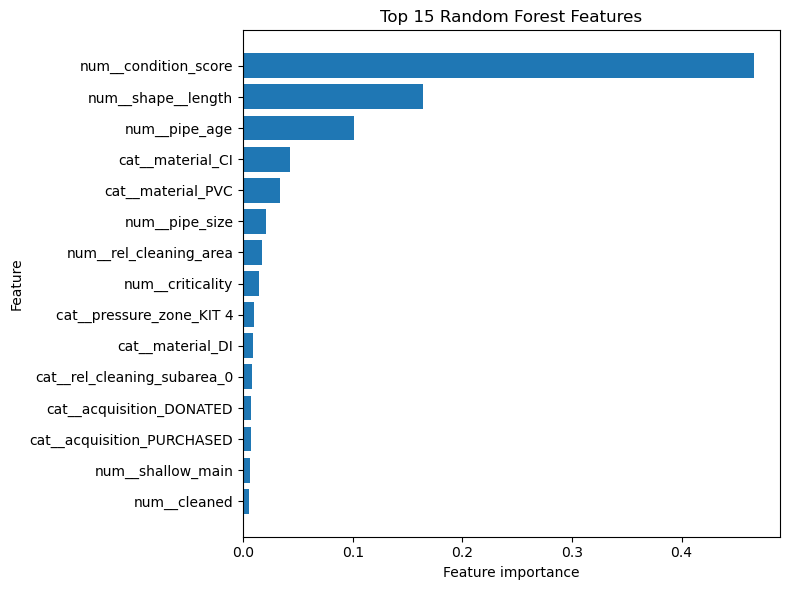

In [12]:
krf.plot_feature_importance(
    rf_results,
    top_n=15,
    save_path="outputs/rf_feature_importance.png"
)

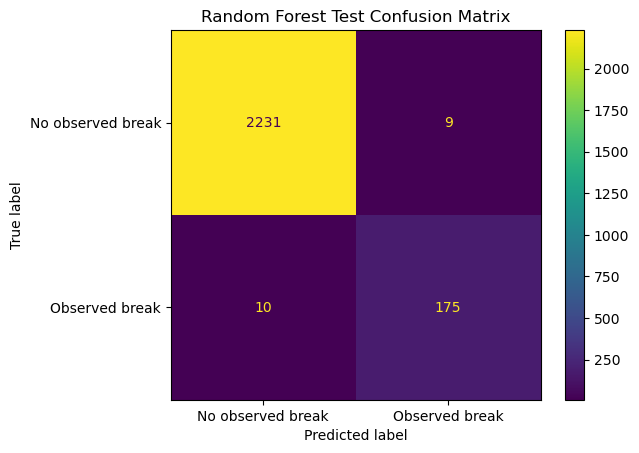

In [14]:
krf.plot_confusion_matrix(
    rf_results,
    save_path="outputs/rf_confusion_matrix.png"
)

### Random Forest result

The Random Forest model performed strongly on both validation and test data. On the test set, it achieved ROC-AUC of 0.9910, PR-AUC of 0.9606, precision of 0.9511, recall of 0.9459 and F1-score of 0.9485.

The test confusion matrix showed 2,231 true negatives, 175 true positives, 9 false positives and 10 false negatives. This indicates that the model was able to identify most observed break cases while keeping false alarms low.

Feature importance showed that `condition_score` was the strongest predictor, followed by `shape__length`, `pipe_age`, and material-related features such as `material_CI` and `material_PVC`. These results suggest that pipe condition, physical dimensions, age, and material were the main drivers of historical break risk.

### 3.2 XGBoost Modelling

This section runs the XGBoost model using the same processed Kitchener model-ready dataset and the same 70/15/15 train, validation and test split.

XGBoost was included because it is a strong gradient boosting model that can capture non-linear patterns and feature interactions. It also supports class weighting and native categorical handling, which is useful for the imbalanced pipe failure dataset.

In [15]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [16]:
import importlib

importlib.reload(kxgb)

from src.kitchener_xgboost import (
    run_xgboost_workflow,
    display_xgboost_summary,
    plot_confusion_matrix,
    plot_feature_importance,
)

xgb_results = kxgb.run_xgboost_workflow(
    data_path="data/processed/kitchener_model_ready.csv",
    target_col="has_break",
    random_state=42,
)

kxgb.display_xgboost_summary(xgb_results)

Data split
Train shape: (11314, 19)
Validation shape: (2424, 19)
Test shape: (2425, 19)

Model settings
Scale pos weight: 12.09
Fixed tuned parameters: {'max_depth': 6, 'learning_rate': 0.04110359181702955, 'subsample': 0.7514526781869276, 'colsample_bytree': 0.6976106662148625, 'min_child_weight': 7, 'gamma': 1.9395005517710073}

Test metrics
roc_auc: 0.9897
pr_auc: 0.9603
precision: 0.9227
recall: 0.9676
f1: 0.9446

Test confusion matrix
[[2225   15]
 [   6  179]]

Top 10 feature importance


,feature,importance
0,condition_score,166.119690
1,material,42.779964
2,shape__length,30.278339
3,pipe_age,17.962099
4,rel_cleaning_subarea,14.987422
5,shallow_main,13.611519
6,pressure_zone,11.965136
7,acquisition,9.131037
8,rel_cleaning_area,8.896902
9,pipe_size,8.219884


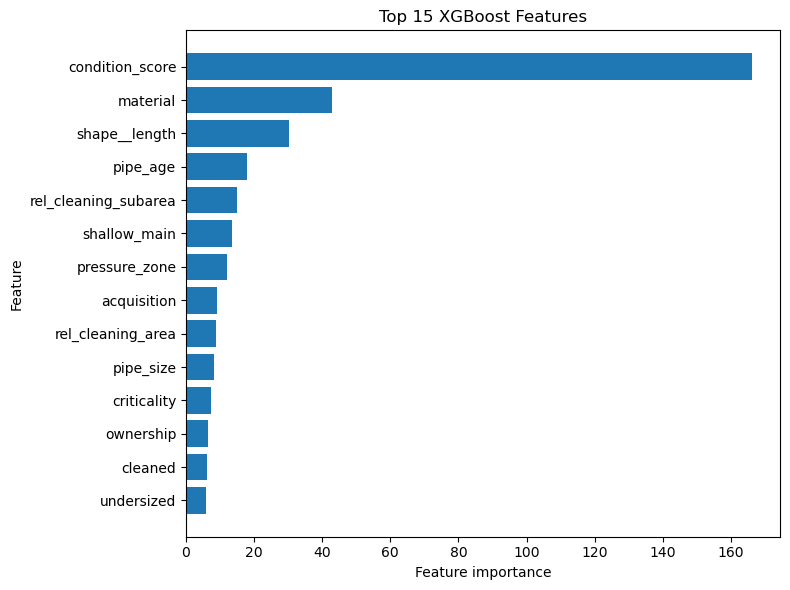

In [17]:
kxgb.plot_feature_importance(
    xgb_results,
    top_n=15,
    save_path="outputs/xgb_feature_importance.png"
)

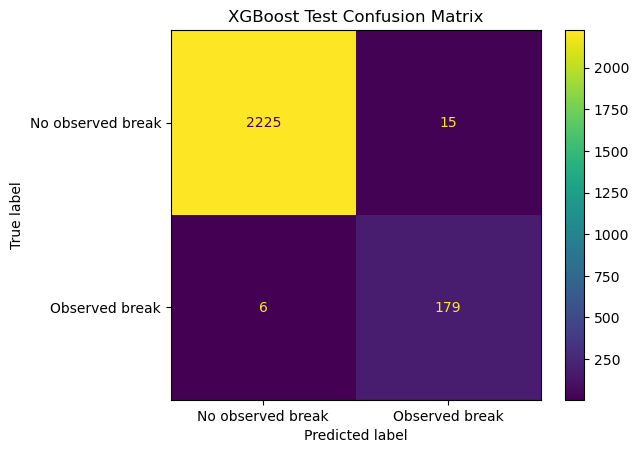

In [18]:
kxgb.plot_confusion_matrix(
    xgb_results,
    save_path="outputs/xgb_confusion_matrix.png"
)

### XGBoost result

The XGBoost model achieved strong test performance, with ROC-AUC of 0.9897, PR-AUC of 0.9603, precision of 0.9227, recall of 0.9676 and F1-score of 0.9446.

The confusion matrix showed 2,225 true negatives and 179 true positives, with 15 false positives and 6 false negatives. Compared with Random Forest, XGBoost captured more break cases while still maintaining strong overall performance.

The feature importance results showed that `condition_score` was the strongest predictor, followed by `material`, `shape__length`, `pipe_age`, and cleaning or network-related variables. This is consistent with the Random Forest findings and supports the use of asset condition, material, length, and age as key transferable risk drivers for Melbourne adaptation.

### 3.3 Logistic Regression Modelling

This section runs the Logistic Regression model using the same processed Kitchener model-ready dataset and the same 70/15/15 train, validation and test split.

Logistic Regression was included as a simpler and more interpretable baseline model. Unlike Random Forest and XGBoost, it assumes a more linear relationship between predictors and the target, making it useful for comparison.

In [19]:
from src.kitchener_logistic_regression import (
    run_logistic_regression_workflow,
    display_logistic_regression_summary,
    plot_confusion_matrix,
    plot_feature_importance,
)

lr_results = run_logistic_regression_workflow(
    data_path="data/processed/kitchener_model_ready.csv",
    target_col="has_break",
    random_state=42,
)

display_logistic_regression_summary(lr_results)

Data split
Train shape: (11314, 19)
Validation shape: (2424, 19)
Test shape: (2425, 19)

Encoded feature space
Encoded train shape: (11314, 95)
Encoded validation shape: (2424, 95)
Encoded test shape: (2425, 95)

Validation metrics
roc_auc: 0.9896
pr_auc: 0.9544
precision: 0.8529
recall: 0.9405
f1: 0.8946

Test metrics
roc_auc: 0.984
pr_auc: 0.9404
precision: 0.7964
recall: 0.9514
f1: 0.867

Test confusion matrix
[[2195   45]
 [   9  176]]

Top 10 coefficients by absolute value


,feature,coefficient,absolute_coefficient
0,condition_score,-6.112316,6.112316
1,material_CI,-1.639346,1.639346
2,shape__length,1.081540,1.081540
3,material_DI,-0.831667,0.831667
4,pipe_age,-0.764224,0.764224
5,pressure_zone_KIT 2W,-0.556849,0.556849
6,undersized,-0.516804,0.516804
7,pressure_zone_KIT 4A,-0.505140,0.505140
8,pressure_zone_KIT 5,0.438440,0.438440
9,pipe_size,-0.393795,0.393795


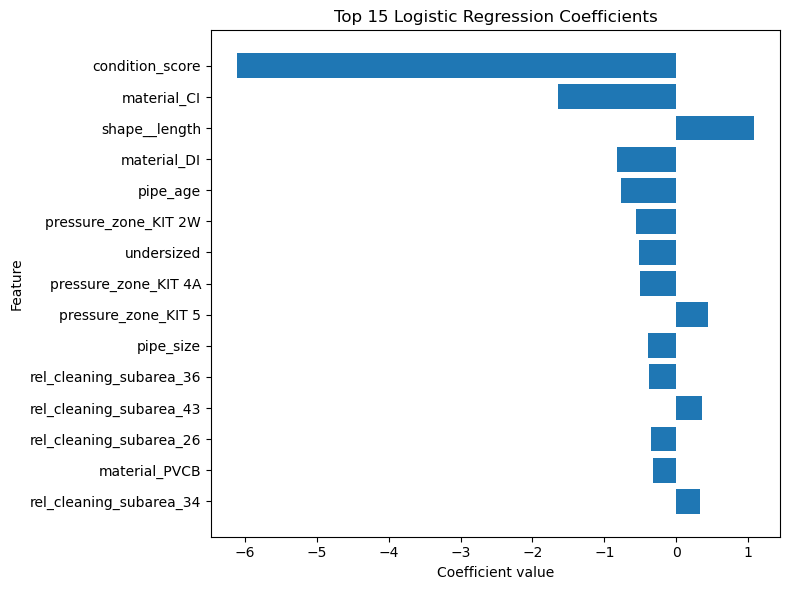

In [20]:
klr.plot_feature_importance(
    lr_results,
    top_n=15,
    save_path="outputs/lr_feature_importance.png"
)

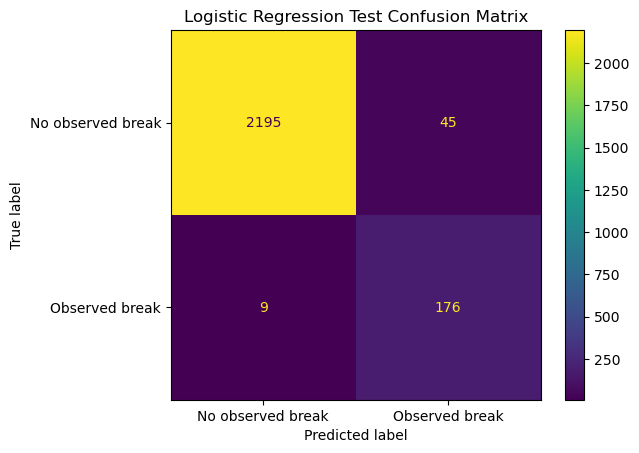

In [21]:
klr.plot_confusion_matrix(
    lr_results,
    save_path="outputs/lr_confusion_matrix.png"
)

### Logistic Regression result

The Logistic Regression model achieved ROC-AUC of 0.9840, PR-AUC of 0.9404, precision of 0.7964, recall of 0.9514 and F1-score of 0.8670 on the test set.

The confusion matrix showed 2,195 true negatives and 176 true positives, with 45 false positives and 9 false negatives. This means the model detected most observed break cases but produced more false alarms than Random Forest and XGBoost.

The coefficient analysis showed that `condition_score` had the strongest influence on prediction, followed by material-related features, `shape__length`, `pipe_age`, pressure zone, and pipe size.

Unlike Random Forest and XGBoost feature importance, Logistic Regression coefficients are signed. Positive coefficients indicate higher association with observed breaks, while negative coefficients indicate lower association. The chart ranks features by absolute coefficient size, so both positive and negative predictors may appear among the top features.

## 4. Melbourne Water Main Data Preprocessing

This section prepares the Melbourne Water main asset data for the later finding adaptation and risk identification stage.

This preprocessing step creates a cleaned pipe-level dataset with transferable asset features such as material, pipe length, pipe width, pipe age and relining information.

In [22]:
from src.melbourne_preprocessing import build_melbourne_cleaned_dataset

melbourne_cleaned = build_melbourne_cleaned_dataset(
    raw_path="data/raw/Melbourne/Water_Supply_Main_Pipelines.csv",
    output_path="data/processed/melbourne_cleaned_for_adaptation.csv",
    current_year=2026,
)

display(melbourne_cleaned.head())
print("Shape:", melbourne_cleaned.shape)

/home/sharchar/Documents/MOP-Code/Playground/Project_3B_T126/src/melbourne_preprocessing.py:92: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  melbourne[col] = pd.to_datetime(melbourne[col], errors="coerce")
/home/sharchar/Documents/MOP-Code/Playground/Project_3B_T126/src/melbourne_preprocessing.py:92: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  melbourne[col] = pd.to_datetime(melbourne[col], errors="coerce")


,ASSET_ID,COMPKEY,UNITID,UNITID2,MAIN_NAME,MAIN_LINE_TYPE,MAIN_CLASS,MATERIAL,PIPE_LENGTH,PIPE_WIDTH,...,HAS_RELINED,YEARS_SINCE_RELINED,MISSING_RELINED_DATE,INVALID_PIPE_LENGTH,INVALID_PIPE_WIDTH,FUTURE_RELINED_DATE,FIELD_TEAM,SERVICE_STATUS,COMMENTS,DATE_LAST_UPDATED
0,M474,296455,M474-00374BR,M474-00377BR,ST GEORGES RD REPLACEMENT MAIN,MAINBG,T,MSCL,2.72,1400.0,...,0,0.0,1,0,0,0,PRESTON,IN,NO COMMENT,2018-09-26 12:31:01
1,Z060,293331,WZ060-ZA,WZ060T101,CARDINIA CREEK MINI HYDRO,MAINAG,S,MSCL,1.88,225.0,...,0,0.0,1,0,0,0,SILVAN,IN,NO COMMENT,2018-03-01 14:04:45
2,M281,1017825,WZ060-01040BR,M281V-EB,CARDINIA-DAND'G-NOTTING HILL M,BYPASS,S,MSCL,1.74,225.0,...,0,0.0,1,0,0,0,SILVAN,IN,NO COMMENT,2018-02-27 00:00:00
3,R144,234582,WR144V-R,WR144-0-0019,TYABB RESERVOIR,MAINBG,S,MS,131.30,100.0,...,0,0.0,1,0,0,0,WESTERNPORT,IN,STORAGE CLEANING PIPE,2018-07-23 12:11:24
4,M281,227935,M281V-EA,WZ060-01040BR,CARDINIA-DAND'G-NOTTING HILL M,BYPASS,S,MSCL,5.26,225.0,...,0,0.0,1,0,0,0,SILVAN,IN,NO COMMENT,2018-02-27 00:00:00


Shape: (12677, 24)


### Melbourne Preprocessing Output Summary

The preprocessing pipeline produced a cleaned Melbourne dataset with **12,677 rows and 24 columns** after removing exact duplicate rows.

Most fields needed for finding adaptation are complete after cleaning, including material, pipe length, pipe width, relining indicators, service status, and operational context.

Some fields still contain missing values:
- `PIPE_AGE` / `DATE_OF_CONSTRUCTION`: 901 missing records
- `DATE_RELINED`: 7,537 missing records
- `DATE_LAST_UPDATED`: 53 missing records

These are acceptable for the next stage because missing construction and relining dates are captured using flags such as `MISSING_CONSTRUCTION_DATE` and `MISSING_RELINED_DATE`.

`COMPKEY` should be used as the main pipe/segment identifier because `ASSET_ID` is repeated across many records.

In [23]:
print("Missing values:")
display(melbourne_cleaned.isna().sum().sort_values(ascending=False))

print("Duplicate rows:", melbourne_cleaned.duplicated().sum())
print("Unique COMPKEY:", melbourne_cleaned["COMPKEY"].nunique())
print("Unique ASSET_ID:", melbourne_cleaned["ASSET_ID"].nunique())

Missing values:


DATE_RELINED                 7537
PIPE_AGE                      901
DATE_OF_CONSTRUCTION          901
DATE_LAST_UPDATED              53
ASSET_ID                        0
COMPKEY                         0
UNITID                          0
UNITID2                         0
MATERIAL                        0
MAIN_CLASS                      0
MAIN_LINE_TYPE                  0
MAIN_NAME                       0
PIPE_LENGTH                     0
MISSING_CONSTRUCTION_DATE       0
HAS_RELINED                     0
PIPE_WIDTH                      0
YEARS_SINCE_RELINED             0
MISSING_RELINED_DATE            0
INVALID_PIPE_WIDTH              0
INVALID_PIPE_LENGTH             0
FUTURE_RELINED_DATE             0
FIELD_TEAM                      0
SERVICE_STATUS                  0
COMMENTS                        0
dtype: int64

Duplicate rows: 0
Unique COMPKEY: 12631
Unique ASSET_ID: 248


#### Melbourne preprocessing result

The Melbourne preprocessing workflow produced a cleaned dataset for finding adaptation and risk scoring.

The output retains key asset-level fields such as `MATERIAL`, `PIPE_LENGTH`, `PIPE_WIDTH`, `PIPE_AGE`, relining indicators, field team and service status. Additional data quality flags were created to preserve important missingness and invalid-value information, including missing construction dates, missing relined dates, invalid pipe length, invalid pipe width and future relined dates.

The dataset does not include a supervised target variable because Melbourne historical break labels were not available. Therefore, this cleaned file is intended for adapting risk drivers identified from the Kitchener models rather than direct supervised training.

## 5. Model Comparison and Melbourne Risk Scoring

This section compares the three Kitchener models and consolidates the strongest transferable risk drivers for Melbourne adaptation.

Because Melbourne does not have confirmed historical break labels, the Kitchener models are not directly applied as supervised prediction models. Instead, their findings are used to build an interpretable Melbourne risk scoring framework.

Model results


,Model,ROC-AUC,PR-AUC,Precision,Recall,F1-score,True Negatives,False Positives,False Negatives,True Positives
0,Logistic Regression,0.9840,0.9404,0.7964,0.9514,0.8670,2195,45,9,176
1,Random Forest,0.9906,0.9596,0.9508,0.9405,0.9457,2231,9,11,174
2,XGBoost,0.9899,0.9614,0.9133,0.9676,0.9396,2223,17,6,179



Model ranking


,Model,ROC-AUC,PR-AUC,Precision,Recall,F1-score,ROC-AUC Rank,PR-AUC Rank,Precision Rank,Recall Rank,F1-score Rank
0,Logistic Regression,0.9840,0.9404,0.7964,0.9514,0.8670,3,3,3,2,3
1,Random Forest,0.9906,0.9596,0.9508,0.9405,0.9457,1,2,1,3,1
2,XGBoost,0.9899,0.9614,0.9133,0.9676,0.9396,2,1,2,1,2


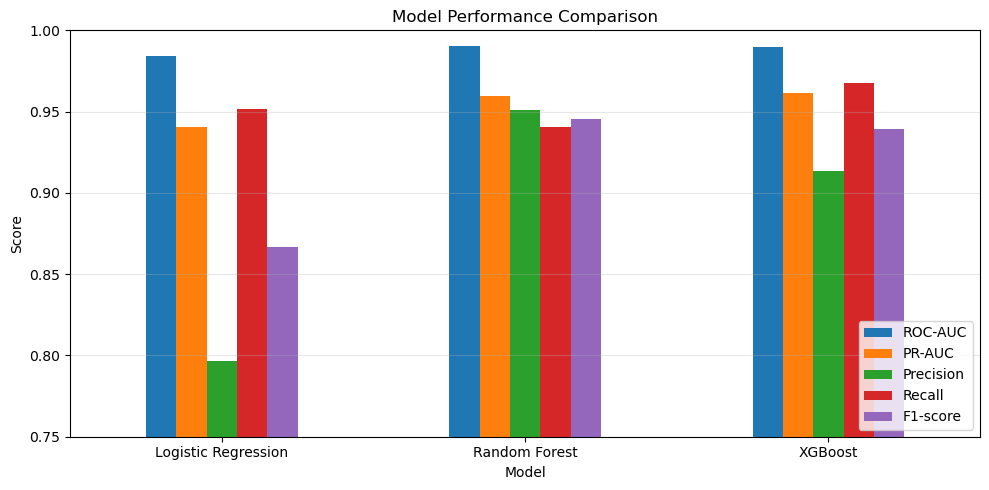

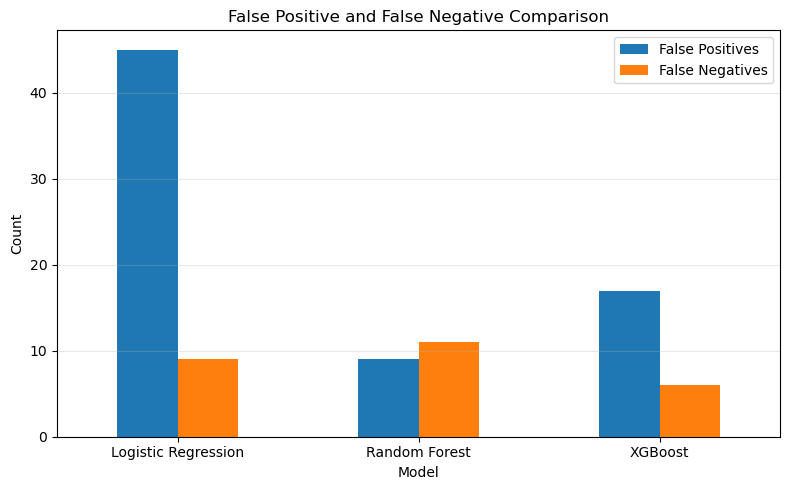

,Risk Driver,Evidence from Kitchener Models,Melbourne Field,Transferability,Use in Melbourne Risk System
0,Pipe Age,Important in tree-based models and linked to d...,PIPE_AGE,High,Older pipes receive higher risk weight
1,Pipe Length,Strong driver in Random Forest and Logistic Re...,PIPE_LENGTH,High,Longer pipe segments receive higher risk weight
2,Material,Material-related features contributed to predi...,MATERIAL,High,Materials associated with higher failure risk ...
3,Pipe Size / Width,Moderate contribution in Random Forest and XGB...,PIPE_WIDTH,Medium,Used as a supporting physical risk factor
4,Condition / Asset Health,Strongest driver through condition_score,Not directly available,Limited,Use proxy features such as age and relining st...
5,Relining / Maintenance History,Lining-related features had lower importance b...,"HAS_RELINED, YEARS_SINCE_RELINED",Medium,No relining or older relining may increase risk
6,Network / Operational Context,Pressure zone and cleaning area contributed to...,"MAIN_LINE_TYPE, MAIN_CLASS, FIELD_TEAM",Medium,Used as context for explanation and grouping


Risk level distribution


RISK_LEVEL
LOW       6938
MEDIUM    5137
HIGH       602
Name: count, dtype: int64


Output shape: (12677, 29)


,ASSET_ID,COMPKEY,MATERIAL,PIPE_LENGTH,PIPE_WIDTH,PIPE_AGE,HAS_RELINED,YEARS_SINCE_RELINED,RISK_SCORE,RISK_LEVEL,RISK_REASONS,RECOMMENDED_ACTION
0,M474,296455,MSCL,2.72,1400.0,9.0,0,0.0,1,LOW,No relining history,Routine monitoring
1,Z060,293331,MSCL,1.88,225.0,9.0,0,0.0,1,LOW,No relining history,Routine monitoring
2,M281,1017825,MSCL,1.74,225.0,15.0,0,0.0,1,LOW,No relining history,Routine monitoring
3,R144,234582,MS,131.30,100.0,9.0,0,0.0,2,LOW,"Long pipe segment, No relining history",Routine monitoring
4,M281,227935,MSCL,5.26,225.0,15.0,0,0.0,1,LOW,No relining history,Routine monitoring


,ASSET_ID,COMPKEY,UNITID,UNITID2,MAIN_NAME,MAIN_LINE_TYPE,MAIN_CLASS,MATERIAL,PIPE_LENGTH,PIPE_WIDTH,...,FUTURE_RELINED_DATE,FIELD_TEAM,SERVICE_STATUS,COMMENTS,DATE_LAST_UPDATED,RISK_SCORE,RISK_LEVEL,RISK_REASONS,RISK_RANK,RECOMMENDED_ACTION
334,M421,236325,M421-11628RED,M421-13024RED,BITTERN - DROMANA NO 1 MAIN,MAINBG,T,RC,738.73,525.0,...,0,WESTERNPORT,IN,NO COMMENT,2014-12-06 01:20:51,8,HIGH,"Very old pipe, Long pipe segment, Higher-risk ...",1,Inspect and prioritise maintenance
379,M421,236323,M421-10321RED,M421-10942RED,BITTERN - DROMANA NO 1 MAIN,MAINBG,T,RC,571.39,675.0,...,0,WESTERNPORT,IN,NO COMMENT,2014-12-06 01:21:07,8,HIGH,"Very old pipe, Long pipe segment, Higher-risk ...",1,Inspect and prioritise maintenance
11318,A014,226694,A014-00039BAS,A014-00783TNL,TARAGO MAIN RACE,AQDUCT,T,RC,602.96,600.0,...,0,TARAGO,IN,CONCRETE FLUME,2019-10-04 14:48:36,8,HIGH,"Aging pipe, Long pipe segment, Higher-risk mat...",1,Inspect and prioritise maintenance
2858,M421,231594,M421-07407RED,M421-08163RED,BITTERN - DROMANA NO 1 MAIN,MAINBG,T,RC,1324.75,525.0,...,0,WESTERNPORT,IN,NO COMMENT,2014-12-06 02:37:14,8,HIGH,"Very old pipe, Long pipe segment, Higher-risk ...",1,Inspect and prioritise maintenance
9837,A014,226696,A014-03152BAS,A014-03393BAS,TARAGO MAIN RACE,AQDUCT,T,RC,241.23,600.0,...,0,TARAGO,IN,CONCRETE FLUME,2019-10-04 12:05:07,8,HIGH,"Aging pipe, Long pipe segment, Higher-risk mat...",1,Inspect and prioritise maintenance
9842,A014,226689,A014-03836BAS,A014-04820BAS,TARAGO MAIN RACE,AQDUCT,T,RC,910.02,600.0,...,0,TARAGO,IN,CONCRETE FLUME,2019-10-04 11:45:29,8,HIGH,"Aging pipe, Long pipe segment, Higher-risk mat...",1,Inspect and prioritise maintenance
2741,M421,235579,M421-13024RED,M421-13570RED,BITTERN - DROMANA NO 1 MAIN,MAINBG,T,RC,458.57,675.0,...,0,WESTERNPORT,IN,MEASURED OD OF MAIN - P/T 261M EAST OF HARRISO...,2014-12-05 23:20:33,8,HIGH,"Very old pipe, Long pipe segment, Higher-risk ...",1,Inspect and prioritise maintenance
2681,M421,236314,WH100MV-AJ,M421-02824RED,BITTERN - DROMANA NO 1 MAIN,MAINBG,T,RC,2794.44,675.0,...,0,WESTERNPORT,IN,OUTLET PIPEWORK BITTERN RESERVOIR,2014-12-06 01:20:24,8,HIGH,"Very old pipe, Long pipe segment, Higher-risk ...",1,Inspect and prioritise maintenance
2722,M421,231593,M421-07107RED,M421-07407RED,BITTERN - DROMANA NO 1 MAIN,MAINBG,T,RC,300.85,675.0,...,0,WESTERNPORT,IN,NO COMMENT,2014-12-06 02:37:01,8,HIGH,"Very old pipe, Long pipe segment, Higher-risk ...",1,Inspect and prioritise maintenance
11147,A014,226732,A014-05940BAS,A014-06451BAS,TARAGO MAIN RACE,AQDUCT,T,RC,548.59,600.0,...,0,TARAGO,IN,CONCRETE CHANNEL,2019-10-04 10:51:26,8,HIGH,"Aging pipe, Long pipe segment, Higher-risk mat...",1,Inspect and prioritise maintenance


In [24]:
from src.model_comparison_risk_scoring import (
    run_model_comparison_and_risk_scoring,
    display_model_comparison_summary,
    display_risk_scoring_summary,
    plot_model_performance,
    plot_error_comparison,
)

comparison_results = run_model_comparison_and_risk_scoring(
    melbourne_input_path="data/processed/melbourne_cleaned_for_adaptation.csv",
    melbourne_output_path="data/processed/melbourne_risk_llm_ready.csv",
    output_dir="outputs",
)

display_model_comparison_summary(
    comparison_results["model_results"],
    comparison_results["ranking"],
)

plot_model_performance(
    comparison_results["model_results"],
    save_path="outputs/model_performance_comparison.png",
)

plot_error_comparison(
    comparison_results["model_results"],
    save_path="outputs/model_error_comparison.png",
)

display(comparison_results["risk_drivers"])

display_risk_scoring_summary(comparison_results["melbourne_scored"])

display(comparison_results["high_risk_pipes"])

### Model comparison result

All three models performed strongly on the same Kitchener test set, but each model showed different strengths.

Random Forest achieved the highest precision at 0.9511 and produced only 9 false positives, making it the strongest balanced model overall for minimising unnecessary maintenance alerts.

XGBoost achieved the highest recall at 0.9676 and the fewest false negatives, missing only 6 actual break cases. This makes it the strongest model for operational risk screening where identifying high-risk pipes is prioritised.

Logistic Regression performed well as an interpretable baseline model, achieving strong recall at 0.9514, but it produced 45 false positives and had the lowest F1-score among the three models.

Overall, Random Forest demonstrated the strongest balanced classification performance, while XGBoost demonstrated the strongest break detection capability.

## 6. LLM-Based Maintenance Recommendation System

### Purpose
This stage integrates a Large Language Model (LLM) into the Melbourne risk scoring workflow to convert numerical pipe-risk outputs into readable maintenance recommendations.

The LLM does not predict failures directly. Instead, it interprets the generated risk score, risk level, and pipe attributes to produce concise operational reasoning for maintenance teams.

### Input Dataset for LLM Stage

In [29]:
melbourne_scored = comparison_results["melbourne_scored"]
display(melbourne_scored.head())

,ASSET_ID,COMPKEY,UNITID,UNITID2,MAIN_NAME,MAIN_LINE_TYPE,MAIN_CLASS,MATERIAL,PIPE_LENGTH,PIPE_WIDTH,...,FUTURE_RELINED_DATE,FIELD_TEAM,SERVICE_STATUS,COMMENTS,DATE_LAST_UPDATED,RISK_SCORE,RISK_LEVEL,RISK_REASONS,RISK_RANK,RECOMMENDED_ACTION
0,M474,296455,M474-00374BR,M474-00377BR,ST GEORGES RD REPLACEMENT MAIN,MAINBG,T,MSCL,2.72,1400.0,...,0,PRESTON,IN,NO COMMENT,2018-09-26 12:31:01,1,LOW,No relining history,9849,Routine monitoring
1,Z060,293331,WZ060-ZA,WZ060T101,CARDINIA CREEK MINI HYDRO,MAINAG,S,MSCL,1.88,225.0,...,0,SILVAN,IN,NO COMMENT,2018-03-01 14:04:45,1,LOW,No relining history,9849,Routine monitoring
2,M281,1017825,WZ060-01040BR,M281V-EB,CARDINIA-DAND'G-NOTTING HILL M,BYPASS,S,MSCL,1.74,225.0,...,0,SILVAN,IN,NO COMMENT,2018-02-27 00:00:00,1,LOW,No relining history,9849,Routine monitoring
3,R144,234582,WR144V-R,WR144-0-0019,TYABB RESERVOIR,MAINBG,S,MS,131.30,100.0,...,0,WESTERNPORT,IN,STORAGE CLEANING PIPE,2018-07-23 12:11:24,2,LOW,"Long pipe segment, No relining history",5740,Routine monitoring
4,M281,227935,M281V-EA,WZ060-01040BR,CARDINIA-DAND'G-NOTTING HILL M,BYPASS,S,MSCL,5.26,225.0,...,0,SILVAN,IN,NO COMMENT,2018-02-27 00:00:00,1,LOW,No relining history,9849,Routine monitoring


### Insights / Summary

The LLM recommendation stage successfully translated numerical risk outputs into readable maintenance reasoning that can support infrastructure decision-making. By combining estimated risk levels with pipe attributes such as age, material and pipe length, the workflow generated concise explanations and maintenance recommendations for selected Melbourne water assets.

The integration demonstrated how Large Language Models can improve the interpretability and usability of machine learning outputs within infrastructure management workflows. The Streamlit dashboard additionally provided an interactive interface for reviewing high-risk pipes and generating AI-assisted maintenance reasoning.

A fallback explanation system was also implemented to ensure the dashboard remained operational if the external API became unavailable. While the generated recommendations are useful for supporting prioritisation and maintenance planning, they are intended to complement rather than replace engineering judgement.

## 7. Conclusion

This notebook demonstrated the final end-to-end workflow for water pipe failure risk identification. The Kitchener dataset was selected as the main supervised modelling dataset because it contained both pipe asset records and historical break records. After preprocessing, three models were trained and compared: Logistic Regression, Random Forest, and XGBoost.

The results showed that all three models performed strongly, with Random Forest providing the strongest balanced classification performance and XGBoost providing the strongest break detection capability. The most consistent risk drivers were pipe condition, material, pipe length, and pipe age.

Because Melbourne data did not include historical break labels, the Kitchener findings were adapted into a Melbourne risk scoring workflow rather than a direct supervised prediction model. The final workflow also demonstrated how an LLM-based recommendation layer can translate risk scores and pipe attributes into practical maintenance reasoning for decision support.